#### LIBRARY IMPORTS

In [1]:
import pandas as pd
import numpy as np
import glob # For file pattern matching for loading files
import os # Certain debugging operations
import joblib # To save scaler and encoder
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

# Neural Netowrk specifc imports
import copy # for deepcopy in save_results()

import torch
import torch.nn as nn # NN layers and loss functions
import torch.optim as optim # Optimization Algorithms
# Batching Data:
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

#### CONFIGURATOINS

In [2]:
FEATURE_ROOT = "speaker_wise-eGeMAPs/functionals"
OUTPUT_ROOT = "model_outputs/neural-network"
RANDOM_SEED = 37
THRESHOLD = 0.5
TRAIN_RATIO = 0.8
VAL_RATIO = 0.1
TEST_RATIO = 0.1
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHILD_SPEAKER = {
     
    "speaker_functional_p5-s2.csv": "SPEAKER_00",
    "speaker_functional_p5-s7.csv": "SPEAKER_01",
    "speaker_functional_p5-s8.csv": "SPEAKER_05",
    "speaker_functional_p5-s10.csv": "SPEAKER_01",
    "speaker_functional_p5-s13.csv": "SPEAKER_01",

    "speaker_functional_p7-s5.csv": "SPEAKER_01",
    "speaker_functional_p7-s6.csv": "SPEAKER_08",
    "speaker_functional_p7-s7.csv": "SPEAKER_02",
    "speaker_functional_p7-s8.csv": "SPEAKER_00",
    "speaker_functional_p7-s16.csv": "SPEAKER_00",
    "speaker_functional_p7-s17.csv": "SPEAKER_00",
    "speaker_functional_p7-s18.csv": "SPEAKER_02",
    "speaker_functional_p7-s29.csv": "SPEAKER_00",

    "speaker_functional_p9-s3-1.csv": "SPEAKER_01",
    "speaker_functional_p9-s3-2.csv": "SPEAKER_04",
    "speaker_functional_p9-s4.csv": "SPEAKER_06",
    "speaker_functional_p9-s9.csv": "SPEAKER_03",
    "speaker_functional_p9-s15.csv": "SPEAKER_01",

    "speaker_functional_p11-s2.csv": "SPEAKER_02",
    "speaker_functional_p11-s4.csv": "SPEAKER_01",
    "speaker_functional_p11-s8.csv": "SPEAKER_03",
    "speaker_functional_p11-s9.csv": "SPEAKER_00",
    "speaker_functional_p11-s11.csv": "SPEAKER_05",
    "speaker_functional_p11-s15.csv": "SPEAKER_00",
    "speaker_functional_p11-s16-2.csv": "SPEAKER_01",
    "speaker_functional_p11-s19.csv": "SPEAKER_00",
    "speaker_functional_p11-s22-2.csv": "SPEAKER_02",

    "speaker_functional_p12-s2-2.csv": "SPEAKER_00",
    "speaker_functional_p12-s3.csv": "SPEAKER_01",
    "speaker_functional_p12-s6.csv": "SPEAKER_01",
    "speaker_functional_p12-s8.csv": "SPEAKER_00",
    "speaker_functional_p12-s10.csv": "SPEAKER_03",

    "speaker_functional_p17-s2.csv": "SPEAKER_01",
    "speaker_functional_p17-s3.csv": "SPEAKER_04",
    "speaker_functional_p17-s5.csv": "SPEAKER_04",
    "speaker_functional_p17-s6.csv": "SPEAKER_02",

    "speaker_functional_p18-s3.csv": "SPEAKER_00",
    "speaker_functional_p18-s4.csv": "SPEAKER_01",
    "speaker_functional_p18-s5.csv": "SPEAKER_00",
    "speaker_functional_p18-s7.csv": "SPEAKER_01",
    "speaker_functional_p18-s8.csv": "SPEAKER_00",
    "speaker_functional_p18-s9.csv": "SPEAKER_01",
    "speaker_functional_p18-s10.csv": "SPEAKER_06",
    "speaker_functional_p18-s11.csv": "SPEAKER_00",
    "speaker_functional_p18-s12.csv": "SPEAKER_00",
    "speaker_functional_p18-s13.csv": "SPEAKER_01",
    "speaker_functional_p18-s15.csv": "SPEAKER_02",
    "speaker_functional_p18-s17.csv": "SPEAKER_01",
    "speaker_functional_p18-s18.csv": "SPEAKER_00",
    "speaker_functional_p18-s19.csv": "SPEAKER_02",
    "speaker_functional_p18-s20.csv": "SPEAKER_01",

}

#### FUNCTIONS

In [3]:
# Early stopping
PATIENCE = 10 # Stop after 10 epochs of no improvement in validation loss

In [4]:
def load_participant_data(participant_folder):
    csv_files = sorted(glob.glob(f"{FEATURE_ROOT}/{participant_folder}/*.csv")) # For multiple files

    def load_single_speaker(csv_path):
        df = pd.read_csv(csv_path)    
        filename = os.path.basename(csv_path)

        if filename not in CHILD_SPEAKER:
            raise ValueError(
                f"No child speaker mapping for {filename}"
            )
        
        target_speaker = CHILD_SPEAKER[filename]

        df = df[df["speaker"] == target_speaker]

        return df
    
    # Train / Validation / Test Split
    
    print(f"{participant_folder}: {len(csv_files)} CSV files")
    
    
    # Load every session for this participant
    full_df = pd.concat(
        [
            load_single_speaker(f)
            for f in csv_files
        ],
        ignore_index=True
    )

    print(f"Total child utterances: {len(full_df)}")
    
    # Remove unnecessary columns
    drop_cols = [
        "participant",
        "session",
        "clip_id",
        "speaker",

        "engagement_start_time",
        "engagement_end_time",

        "speaker_start_time",
        "speaker_end_time",

        "num_segments",
        "speech_duration",
    ]

    full_df = full_df.drop(
        columns=[c for c in drop_cols if c in full_df.columns]
    )

    print(full_df.columns)

    # Separate Features and Labels
    X = full_df.drop(columns=["label"])
    y = full_df["label"]

    return (
        X.reset_index(drop=True),
        y.reset_index(drop=True)
    )

In [5]:
def preprocess_data(X_train, X_val, X_test, y_train, y_val, y_test):
    
    # Label Encoding
    encoder = LabelEncoder()
    y_train = encoder.fit_transform(y_train)
    y_val = encoder.transform(y_val)
    y_test = encoder.transform(y_test)

    # Print for debugging purpose
    print(encoder.classes_)
    print(np.unique(y_train))
    print(np.unique(y_val))
    print(np.unique(y_test))

    # Feature Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train) # Learn the Meand and std and transform the data
    X_val = scaler.transform(X_val) # Transform the data using the learned mean and std
    X_test = scaler.transform(X_test) # Transform the data using the learned mean and std

    return (
        X_train,
        X_val,
        X_test,
        y_train,
        y_val,
        y_test,
        scaler,
        encoder
    )  

In [6]:
class NeuralNetwork(nn.Module):

    # Define the architecture of the neural network ; Constructor
    def __init__(self, input_dim):

        super().__init__() # Initialize the parent class (nn.Module) first, then inherit functionalities

        self.network = nn.Sequential(
            # First Hidden Layer 88 -> 128 nueruons
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Second Hidden Layer 128 -> 64 nueruons
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Output Layer 64 -> 1 nuerons
            nn.Linear(64, 1)

        )
    
    # Forward pass through the network; Automatically called  when calling model; Then return the model predictions
    def forward(self, x):
        return self.network(x)


# Build the model, then move it to GPU/ CPU and print the model architecture
def build_model(input_dim):
    # Build model
    model = NeuralNetwork(input_dim)
    
    # Move model to GPU/ CPU
    model.to(DEVICE)
    
    print(model)

    return model

In [7]:
def train_model(
        model,
        train_loader,
        val_loader
):
    # BCEWithLogitsLoss is good for our case of binary classification
    # It performs sigmoid + Binary Cross Entropy Loss 
    criterion = nn.BCEWithLogitsLoss()

    # Adam optimizer
    optimizer = optim.Adam(
        model.parameters(),
        lr=0.0005
    )

    # Initialize best loss to be infinity and patience counter to 0
    best_loss = float("inf")
    patience_counter = 0

    # Store training and validation loss for each epoch (perhaps for plotting later)
    history = {
        "train_loss": [],
        "val_loss": []
    }

    # Epoch Loop; Max is 100, but may stop earlier due to early stopping
    for epoch in range(100):

        #TRAINING

        # Activate training (Dropout layers and gradient computation)
        model.train()

        train_loss = 0

        # Train Batch-wise (32)
        for X_batch, y_batch in train_loader:
            
            # Move batch to GPU/ CPU
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            # Reset the gradients before backpropagation
            optimizer.zero_grad()

            # Foeward pass prediction
            outputs = model(X_batch)

            # Compute loss
            loss = criterion(outputs, y_batch)

            # Backpropagation 
            # Computes gradients
            loss.backward()
            # Update weights using optimizer
            optimizer.step()

            train_loss += loss.item() # loss is a tensor

        # Average traingin loss per batch
        train_loss /= len(train_loader)

        # VALIDATION
        
        # Turn off training (Dropout layers and gradient computation)
        model.eval()

        val_loss = 0

        # Disable gradient computation
        with torch.no_grad():
            # Validate Batch-wise (32)
            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(DEVICE)
                y_batch = y_batch.to(DEVICE)

                outputs = model(X_batch)

                loss = criterion(outputs, y_batch)

                val_loss += loss.item()

        val_loss /= len(val_loader)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(
            f"Epoch {epoch+1} "
            f"Train={train_loss:.4f} "
            f"Val={val_loss:.4f}"
        )

        # If validation loss improves, save the model weights and reset patience counter
        if val_loss < best_loss:
            best_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0

        # If validation loss does not improve, increment patience counter and check for early stopping
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                print("Early stopping")
                break

    # Restore the best model weights after training is complete
    model.load_state_dict(best_weights)

    return history

In [8]:
def evaluate_model(
        model,
        test_loader,
        encoder
):
    # No dropouts
    model.eval()

    probabilities = []
    predictions = []
    actual = []

    # Disable gradient computation
    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(DEVICE)

            # Forward pass prediction
            outputs = model(X_batch)
            
            # Apply sigmoid to get probabilities
            probs = torch.sigmoid(outputs)

            # Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
            preds = (probs >= THRESHOLD).float()

            # NumPy cannotread GPU tensors, so we need to move them to CPU and convert to NumPy arrays before storing them in lists
            probabilities.extend(probs.cpu().numpy().flatten())
            predictions.extend(preds.cpu().numpy().flatten())
            
            actual.extend(y_batch.numpy().flatten())

    # Convert lists to NumPy arrays and ensure they are of integer type
    probabilities = np.array(probabilities).astype(float)
    predictions = np.array(predictions).astype(int)
    actual = np.array(actual).astype(int)

    # DEBUGGING STATEMENTS

    print("\nActual class counts:")
    print(pd.Series(actual).value_counts()) 

    print("\nPredicted class counts:")
    print(pd.Series(predictions).value_counts())

    print("\nPredicted probabilities:")
    print(probabilities[:20])

    print(f"\nMinimum probability : {probabilities.min():.3f}")
    print(f"Maximum probability : {probabilities.max():.3f}")
    print(f"Average probability : {probabilities.mean():.3f}")

    # actual contains the true labels
    engaged_probs = probabilities[actual == 1]
    disengaged_probs = probabilities[actual == 0]

    print("\nProbability Statistics")
    print("----------------------")
    print(f"Engaged mean      : {engaged_probs.mean():.3f}")
    print(f"Engaged std       : {engaged_probs.std():.3f}")
    print(f"Disengaged mean   : {disengaged_probs.mean():.3f}")
    print(f"Disengaged std    : {disengaged_probs.std():.3f}")

    plt.figure(figsize=(6,4))
    plt.hist(engaged_probs, bins=15, alpha=0.6, label="Engaged")
    plt.hist(disengaged_probs, bins=15, alpha=0.6, label="Disengaged")
    plt.xlabel("Predicted Probability")
    plt.ylabel("Count")
    plt.legend()
    plt.show()

        # Confusion Matrix
    cm = confusion_matrix(actual, predictions)

    # Compute metrics
    metrics_dictionary = {
        "Accuracy": accuracy_score(actual, predictions),
        "Precision": precision_score(actual, predictions),
        "Recall": recall_score(actual, predictions),
        "F1 Score": f1_score(actual, predictions)
    }

    report = classification_report(
        actual,
        predictions,
        target_names=encoder.classes_,
        output_dict=True
    )

    print(classification_report(
        actual,
        predictions,
        target_names=encoder.classes_
    ))

    return {
        "metrics": metrics_dictionary,
        "predictions": predictions,
        "probabilities": probabilities,
        "actual": actual,
        "confusion_matrix": cm,
        "classification_report": report
    }

In [9]:
''' The following are saved:
    Model weights (model.pt)
    Scaler (scaler.pkl)
    Encoder (encoder.pkl)
    Training History (history.csv)
    Metrics (metrics.csv)
    Confusion Matrix (confusion_matrix.csv)
    Classification Report (classification_report.csv) '''
    
def save_results(
        participant,
        model,
        scaler,
        encoder,
        history,
        evaluation
    ):
    
    metrics = evaluation["metrics"]
    predictions = evaluation["predictions"]
    probabilities = evaluation["probabilities"]
    actual = evaluation["actual"]
    cm = evaluation["confusion_matrix"]
    report = evaluation["classification_report"]
    
    # Save Model
    participant_output = Path(OUTPUT_ROOT, participant)
    os.makedirs(participant_output, exist_ok=True)
    torch.save(model.state_dict(),participant_output / "model.pt")
    
    # Save Scaler
    joblib.dump(scaler,Path(participant_output, "scaler.pkl"))
    
    # Save Encoder
    joblib.dump(encoder,Path(participant_output, "encoder.pkl"))
    
    # Save History
    history_df = pd.DataFrame(history)
    history_df.to_csv(Path(participant_output, "history.csv"),index=False)
    
    # Save Metrics
    metrics_df = pd.DataFrame([metrics])

    metrics_df.to_csv(Path(participant_output, "metrics.csv"),index=False)
        
    # Save Confusion Matrix
    cm_df = pd.DataFrame(cm,index=encoder.classes_,columns=encoder.classes_)
    cm_df.to_csv(Path(participant_output, "confusion_matrix.csv"))
    
    # Save classification report
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(Path(participant_output, "classification_report.csv"))
    
    # Save predictions
    prediction_df = pd.DataFrame({
        "Actual": actual,
        "Prediction": predictions,
        "Probability": probabilities
    })

    prediction_df.to_csv(Path(participant_output, "predictions.csv"),index=False)

#### RUN MODEL

Training p11
p11: 9 CSV files
Total child utterances: 272
Index(['F0semitoneFrom27.5Hz_sma3nz_amean',
       'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
       'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
       'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
       'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean',
       'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0',
       'loudness_sma3_percentile50.0', 'loudness_sma3_percentile80.0',
       'loudness_sma3_pctlrange0-2', 'loudness_sma3_meanRisingSlope',
       'loudness_sma3_stddevRisingSlope', 'loudness_sma3_meanFallingSlope',
       'loudness_sma3_stddevFallingSlope', 'spectralFlux_sma3_amean',
       'spectralFlux_sma3_stddevNorm', '

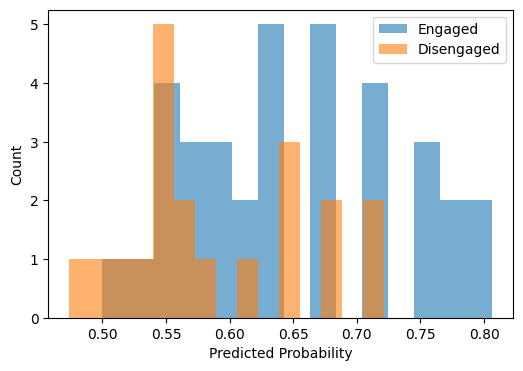

              precision    recall  f1-score   support

  disengaged       0.67      0.10      0.17        20
     engaged       0.65      0.97      0.78        35

    accuracy                           0.65        55
   macro avg       0.66      0.54      0.48        55
weighted avg       0.66      0.65      0.56        55


Fold 2/5

Training class distribution:
label
engaged       111
disengaged     62
Name: count, dtype: int64

Validation class distribution:
label
engaged       28
disengaged    16
Name: count, dtype: int64

Testing class distribution:
label
engaged       35
disengaged    20
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True

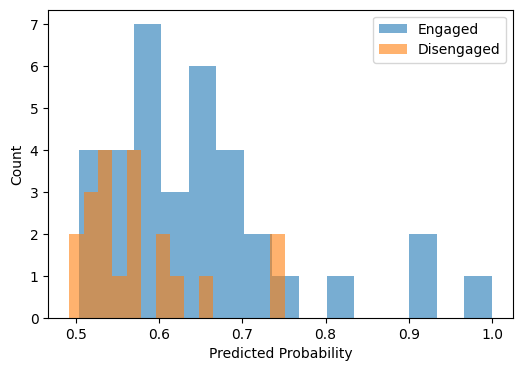

              precision    recall  f1-score   support

  disengaged       1.00      0.05      0.10        20
     engaged       0.65      1.00      0.79        35

    accuracy                           0.65        55
   macro avg       0.82      0.53      0.44        55
weighted avg       0.78      0.65      0.54        55


Fold 3/5

Training class distribution:
label
engaged       111
disengaged     63
Name: count, dtype: int64

Validation class distribution:
label
engaged       28
disengaged    16
Name: count, dtype: int64

Testing class distribution:
label
engaged       35
disengaged    19
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True

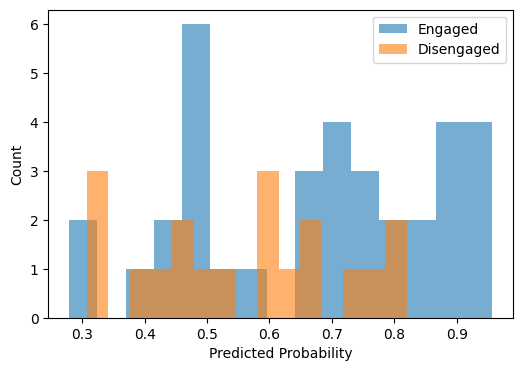

              precision    recall  f1-score   support

  disengaged       0.47      0.42      0.44        19
     engaged       0.70      0.74      0.72        35

    accuracy                           0.63        54
   macro avg       0.59      0.58      0.58        54
weighted avg       0.62      0.63      0.62        54


Fold 4/5

Training class distribution:
label
engaged       111
disengaged     63
Name: count, dtype: int64

Validation class distribution:
label
engaged       28
disengaged    16
Name: count, dtype: int64

Testing class distribution:
label
engaged       35
disengaged    19
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True

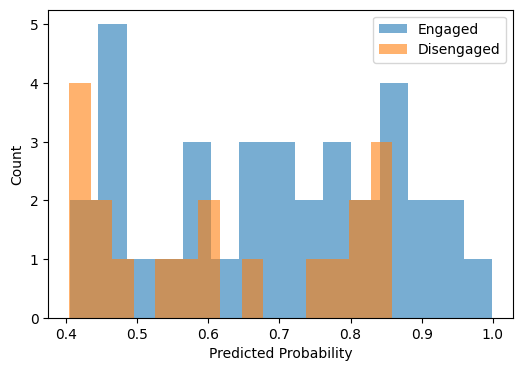

              precision    recall  f1-score   support

  disengaged       0.47      0.37      0.41        19
     engaged       0.69      0.77      0.73        35

    accuracy                           0.63        54
   macro avg       0.58      0.57      0.57        54
weighted avg       0.61      0.63      0.62        54


Fold 5/5

Training class distribution:
label
engaged       112
disengaged     62
Name: count, dtype: int64

Validation class distribution:
label
engaged       28
disengaged    16
Name: count, dtype: int64

Testing class distribution:
label
engaged       34
disengaged    20
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True

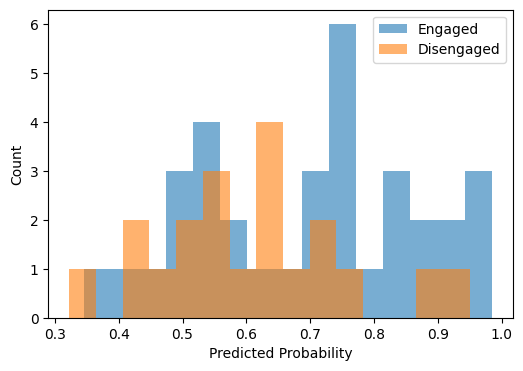

              precision    recall  f1-score   support

  disengaged       0.50      0.20      0.29        20
     engaged       0.65      0.88      0.75        34

    accuracy                           0.63        54
   macro avg       0.58      0.54      0.52        54
weighted avg       0.60      0.63      0.58        54

Training p12
p12: 5 CSV files
Total child utterances: 261
Index(['F0semitoneFrom27.5Hz_sma3nz_amean',
       'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
       'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
       'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
       'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean',
       'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0',


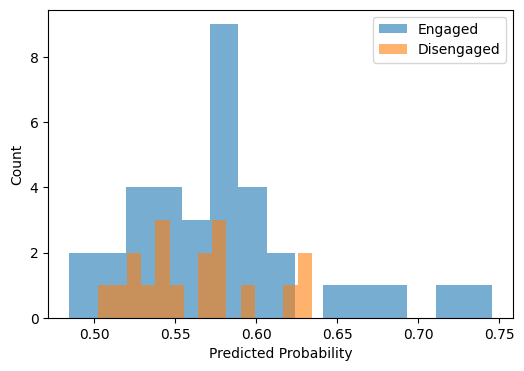

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00        18
     engaged       0.65      0.97      0.78        35

    accuracy                           0.64        53
   macro avg       0.33      0.49      0.39        53
weighted avg       0.43      0.64      0.52        53


Fold 2/5

Training class distribution:
label
engaged       110
disengaged     57
Name: count, dtype: int64

Validation class distribution:
label
engaged       28
disengaged    14
Name: count, dtype: int64

Testing class distribution:
label
engaged       34
disengaged    18
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True

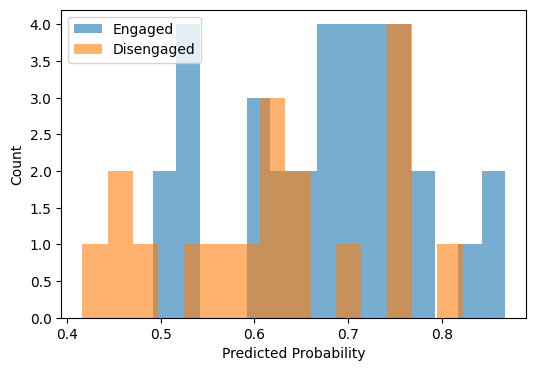

              precision    recall  f1-score   support

  disengaged       0.80      0.22      0.35        18
     engaged       0.70      0.97      0.81        34

    accuracy                           0.71        52
   macro avg       0.75      0.60      0.58        52
weighted avg       0.74      0.71      0.65        52


Fold 3/5

Training class distribution:
label
engaged       110
disengaged     57
Name: count, dtype: int64

Validation class distribution:
label
engaged       28
disengaged    14
Name: count, dtype: int64

Testing class distribution:
label
engaged       34
disengaged    18
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True

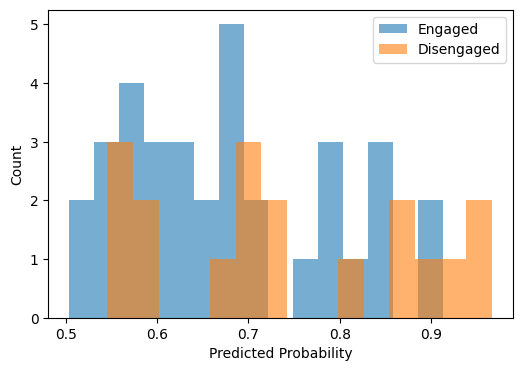

/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00        18
     engaged       0.65      1.00      0.79        34

    accuracy                           0.65        52
   macro avg       0.33      0.50      0.40        52
weighted avg       0.43      0.65      0.52        52


Fold 4/5

Training class distribution:
label
engaged       110
disengaged     57
Name: count, dtype: int64

Validation class distribution:
label
engaged       28
disengaged    14
Name: count, dtype: int64

Testing class distribution:
label
engaged       34
disengaged    18
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True

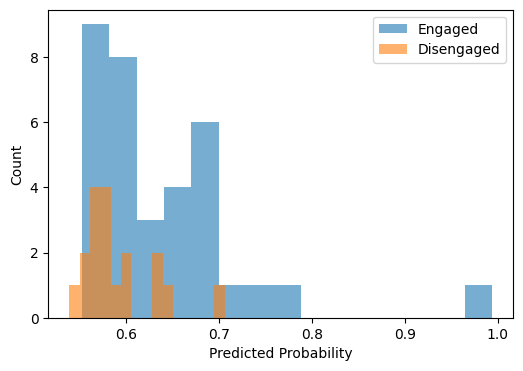

/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00        18
     engaged       0.65      1.00      0.79        34

    accuracy                           0.65        52
   macro avg       0.33      0.50      0.40        52
weighted avg       0.43      0.65      0.52        52


Fold 5/5

Training class distribution:
label
engaged       109
disengaged     58
Name: count, dtype: int64

Validation class distribution:
label
engaged       28
disengaged    14
Name: count, dtype: int64

Testing class distribution:
label
engaged       35
disengaged    17
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True

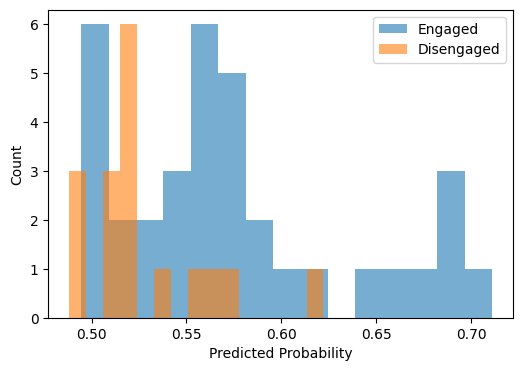

              precision    recall  f1-score   support

  disengaged       0.43      0.18      0.25        17
     engaged       0.69      0.89      0.78        35

    accuracy                           0.65        52
   macro avg       0.56      0.53      0.51        52
weighted avg       0.60      0.65      0.60        52

Training p17
p17: 4 CSV files
Total child utterances: 81
Index(['F0semitoneFrom27.5Hz_sma3nz_amean',
       'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
       'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
       'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
       'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean',
       'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0',
 

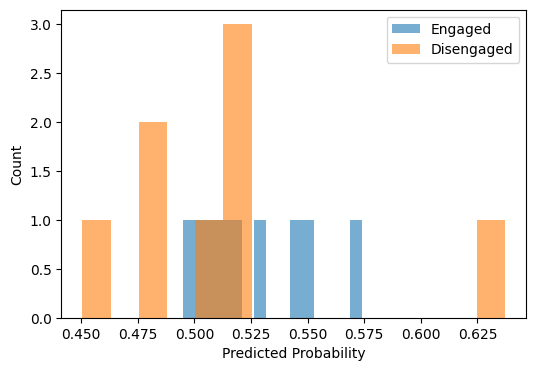

              precision    recall  f1-score   support

  disengaged       0.75      0.38      0.50         8
     engaged       0.62      0.89      0.73         9

    accuracy                           0.65        17
   macro avg       0.68      0.63      0.61        17
weighted avg       0.68      0.65      0.62        17


Fold 2/5

Training class distribution:
label
engaged       29
disengaged    23
Name: count, dtype: int64

Validation class distribution:
label
engaged       7
disengaged    6
Name: count, dtype: int64

Testing class distribution:
label
engaged       9
disengaged    7
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )


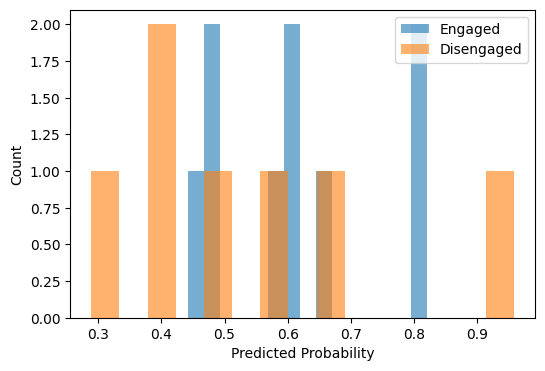

              precision    recall  f1-score   support

  disengaged       0.57      0.57      0.57         7
     engaged       0.67      0.67      0.67         9

    accuracy                           0.62        16
   macro avg       0.62      0.62      0.62        16
weighted avg       0.62      0.62      0.62        16


Fold 3/5

Training class distribution:
label
engaged       29
disengaged    23
Name: count, dtype: int64

Validation class distribution:
label
engaged       7
disengaged    6
Name: count, dtype: int64

Testing class distribution:
label
engaged       9
disengaged    7
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )


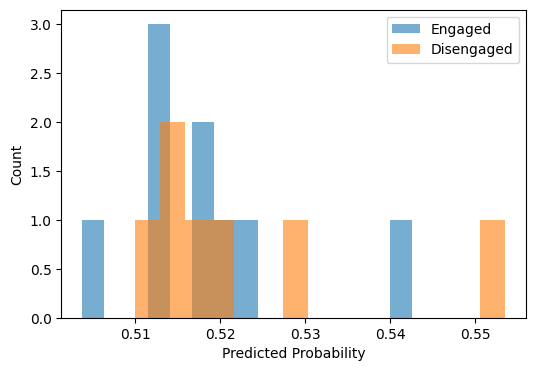

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00         7
     engaged       0.56      1.00      0.72         9

    accuracy                           0.56        16
   macro avg       0.28      0.50      0.36        16
weighted avg       0.32      0.56      0.40        16


Fold 4/5

Training class distribution:
label
engaged       29
disengaged    23
Name: count, dtype: int64

Validation class distribution:
label
engaged       7
disengaged    6
Name: count, dtype: int64

Testing class distribution:
label
engaged       9
disengaged    7
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )


/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

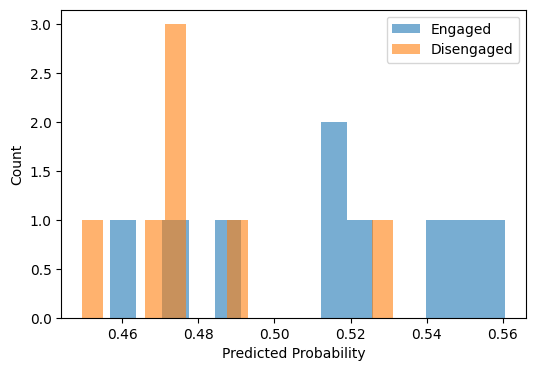

              precision    recall  f1-score   support

  disengaged       0.67      0.86      0.75         7
     engaged       0.86      0.67      0.75         9

    accuracy                           0.75        16
   macro avg       0.76      0.76      0.75        16
weighted avg       0.77      0.75      0.75        16


Fold 5/5

Training class distribution:
label
engaged       29
disengaged    23
Name: count, dtype: int64

Validation class distribution:
label
engaged       7
disengaged    6
Name: count, dtype: int64

Testing class distribution:
label
engaged       9
disengaged    7
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )


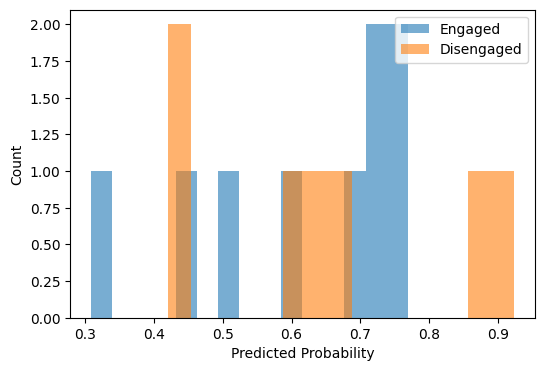

              precision    recall  f1-score   support

  disengaged       0.50      0.29      0.36         7
     engaged       0.58      0.78      0.67         9

    accuracy                           0.56        16
   macro avg       0.54      0.53      0.52        16
weighted avg       0.55      0.56      0.53        16

Training p18
p18: 15 CSV files
Total child utterances: 169
Index(['F0semitoneFrom27.5Hz_sma3nz_amean',
       'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
       'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
       'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
       'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean',
       'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0',

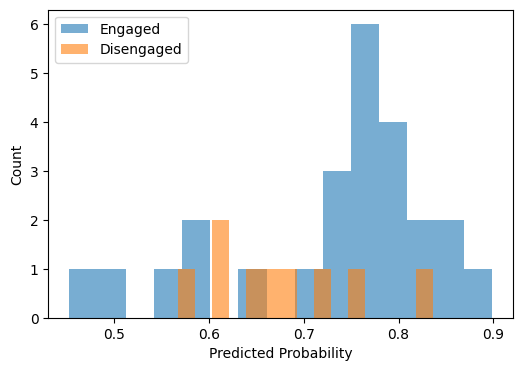

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00         9
     engaged       0.73      0.96      0.83        25

    accuracy                           0.71        34
   macro avg       0.36      0.48      0.41        34
weighted avg       0.53      0.71      0.61        34


Fold 2/5

Training class distribution:
label
engaged       78
disengaged    30
Name: count, dtype: int64

Validation class distribution:
label
engaged       19
disengaged     8
Name: count, dtype: int64

Testing class distribution:
label
engaged       25
disengaged     9
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)


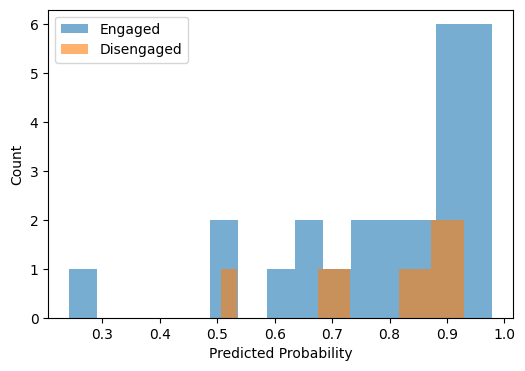

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00         9
     engaged       0.72      0.92      0.81        25

    accuracy                           0.68        34
   macro avg       0.36      0.46      0.40        34
weighted avg       0.53      0.68      0.59        34


Fold 3/5

Training class distribution:
label
engaged       78
disengaged    30
Name: count, dtype: int64

Validation class distribution:
label
engaged       20
disengaged     7
Name: count, dtype: int64

Testing class distribution:
label
engaged       24
disengaged    10
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)


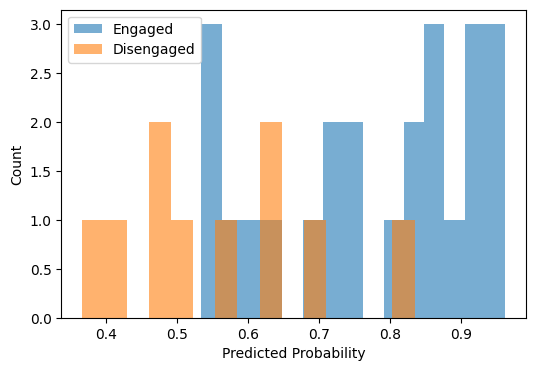

              precision    recall  f1-score   support

  disengaged       1.00      0.40      0.57        10
     engaged       0.80      1.00      0.89        24

    accuracy                           0.82        34
   macro avg       0.90      0.70      0.73        34
weighted avg       0.86      0.82      0.80        34


Fold 4/5

Training class distribution:
label
engaged       78
disengaged    30
Name: count, dtype: int64

Validation class distribution:
label
engaged       20
disengaged     7
Name: count, dtype: int64

Testing class distribution:
label
engaged       24
disengaged    10
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)


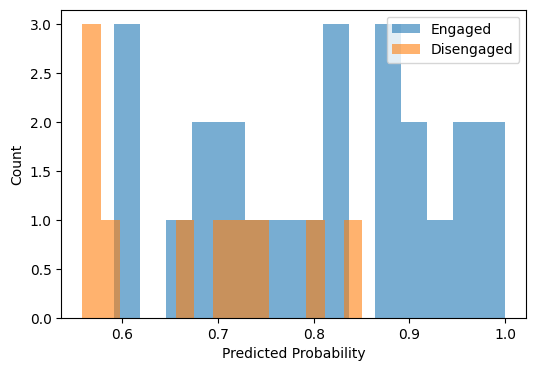

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00        10
     engaged       0.71      1.00      0.83        24

    accuracy                           0.71        34
   macro avg       0.35      0.50      0.41        34
weighted avg       0.50      0.71      0.58        34


Fold 5/5

Training class distribution:
label
engaged       78
disengaged    30
Name: count, dtype: int64

Validation class distribution:
label
engaged       20
disengaged     8
Name: count, dtype: int64

Testing class distribution:
label
engaged       24
disengaged     9
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)


/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

Epoch 4 Train=0.6250 Val=0.6252
Epoch 5 Train=0.6006 Val=0.6126
Epoch 6 Train=0.5805 Val=0.6009
Epoch 7 Train=0.5640 Val=0.5913
Epoch 8 Train=0.5666 Val=0.5827
Epoch 9 Train=0.5541 Val=0.5760
Epoch 10 Train=0.5050 Val=0.5709
Epoch 11 Train=0.5163 Val=0.5678
Epoch 12 Train=0.5076 Val=0.5657
Epoch 13 Train=0.4823 Val=0.5660
Epoch 14 Train=0.4744 Val=0.5682
Epoch 15 Train=0.4882 Val=0.5711
Epoch 16 Train=0.4386 Val=0.5746
Epoch 17 Train=0.4401 Val=0.5786
Epoch 18 Train=0.4600 Val=0.5835
Epoch 19 Train=0.4016 Val=0.5888
Epoch 20 Train=0.4138 Val=0.5955
Epoch 21 Train=0.3960 Val=0.6027
Epoch 22 Train=0.3688 Val=0.6108
Early stopping

Actual class counts:
1    24
0     9
Name: count, dtype: int64

Predicted class counts:
1    32
0     1
Name: count, dtype: int64

Predicted probabilities:
[0.67943722 0.79234612 0.80781424 0.5263195  0.93013316 0.59937811
 0.97448653 0.66214168 0.99817848 0.84362817 0.51934719 0.6902687
 0.70133281 0.65271193 0.61394501 0.69842404 0.60332352 0.53562856
 0.6379

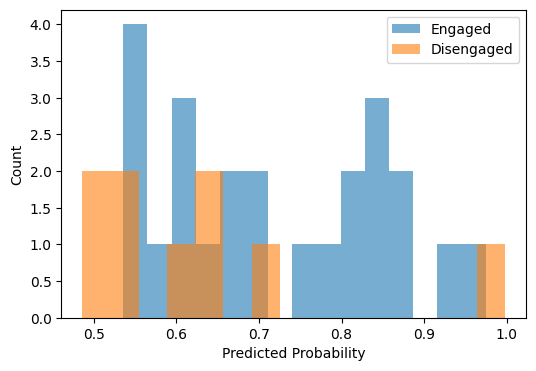

              precision    recall  f1-score   support

  disengaged       1.00      0.11      0.20         9
     engaged       0.75      1.00      0.86        24

    accuracy                           0.76        33
   macro avg       0.88      0.56      0.53        33
weighted avg       0.82      0.76      0.68        33

Training p5
p5: 5 CSV files
Total child utterances: 110
Index(['F0semitoneFrom27.5Hz_sma3nz_amean',
       'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
       'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
       'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
       'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean',
       'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0',
  

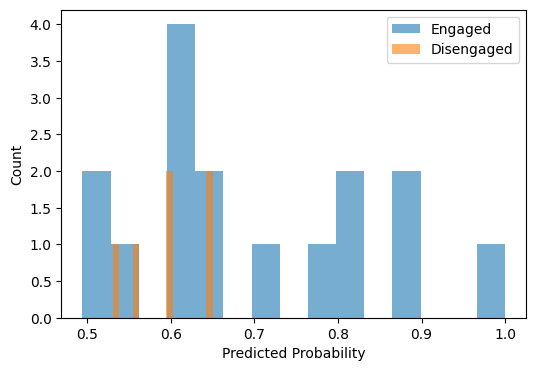

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00         6
     engaged       0.71      0.94      0.81        16

    accuracy                           0.68        22
   macro avg       0.36      0.47      0.41        22
weighted avg       0.52      0.68      0.59        22


Fold 2/5

Training class distribution:
label
engaged       49
disengaged    21
Name: count, dtype: int64

Validation class distribution:
label
engaged       13
disengaged     5
Name: count, dtype: int64

Testing class distribution:
label
engaged       16
disengaged     6
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)


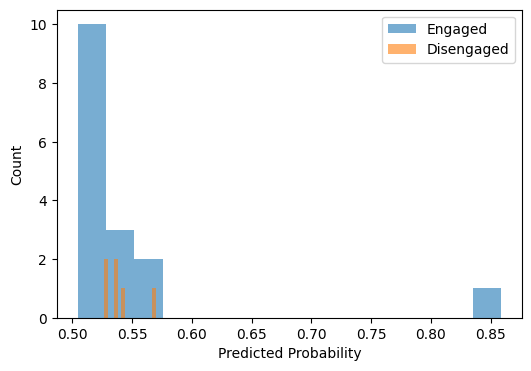

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00         6
     engaged       0.73      1.00      0.84        16

    accuracy                           0.73        22
   macro avg       0.36      0.50      0.42        22
weighted avg       0.53      0.73      0.61        22


Fold 3/5

Training class distribution:
label
engaged       49
disengaged    21
Name: count, dtype: int64

Validation class distribution:
label
engaged       13
disengaged     5
Name: count, dtype: int64

Testing class distribution:
label
engaged       16
disengaged     6
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)


/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

Epoch 1 Train=0.7338 Val=0.6953
Epoch 2 Train=0.7134 Val=0.6842
Epoch 3 Train=0.6899 Val=0.6753
Epoch 4 Train=0.6964 Val=0.6685
Epoch 5 Train=0.6605 Val=0.6646
Epoch 6 Train=0.6483 Val=0.6617
Epoch 7 Train=0.6414 Val=0.6571
Epoch 8 Train=0.6169 Val=0.6536
Epoch 9 Train=0.6273 Val=0.6501
Epoch 10 Train=0.6074 Val=0.6459
Epoch 11 Train=0.6326 Val=0.6429
Epoch 12 Train=0.5809 Val=0.6427
Epoch 13 Train=0.5874 Val=0.6443
Epoch 14 Train=0.6275 Val=0.6463
Epoch 15 Train=0.6056 Val=0.6461
Epoch 16 Train=0.5556 Val=0.6423
Epoch 17 Train=0.5584 Val=0.6412
Epoch 18 Train=0.5156 Val=0.6417
Epoch 19 Train=0.5657 Val=0.6412
Epoch 20 Train=0.5427 Val=0.6380
Epoch 21 Train=0.5127 Val=0.6360
Epoch 22 Train=0.4635 Val=0.6350
Epoch 23 Train=0.4914 Val=0.6349
Epoch 24 Train=0.5329 Val=0.6380
Epoch 25 Train=0.5112 Val=0.6412
Epoch 26 Train=0.4449 Val=0.6421
Epoch 27 Train=0.4377 Val=0.6454
Epoch 28 Train=0.4722 Val=0.6466
Epoch 29 Train=0.4264 Val=0.6507
Epoch 30 Train=0.4432 Val=0.6540
Epoch 31 Train=0.44

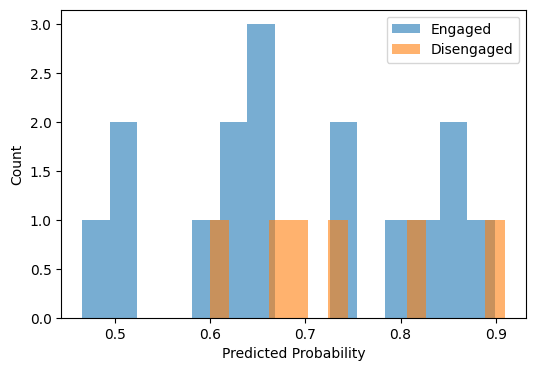

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00         6
     engaged       0.71      0.94      0.81        16

    accuracy                           0.68        22
   macro avg       0.36      0.47      0.41        22
weighted avg       0.52      0.68      0.59        22


Fold 4/5

Training class distribution:
label
engaged       50
disengaged    20
Name: count, dtype: int64

Validation class distribution:
label
engaged       13
disengaged     5
Name: count, dtype: int64

Testing class distribution:
label
engaged       15
disengaged     7
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)


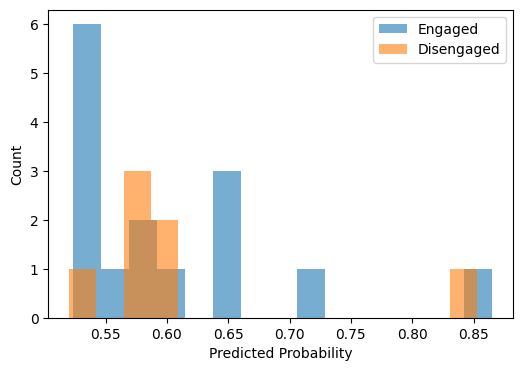

/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00         7
     engaged       0.68      1.00      0.81        15

    accuracy                           0.68        22
   macro avg       0.34      0.50      0.41        22
weighted avg       0.46      0.68      0.55        22


Fold 5/5

Training class distribution:
label
engaged       50
disengaged    20
Name: count, dtype: int64

Validation class distribution:
label
engaged       13
disengaged     5
Name: count, dtype: int64

Testing class distribution:
label
engaged       15
disengaged     7
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)


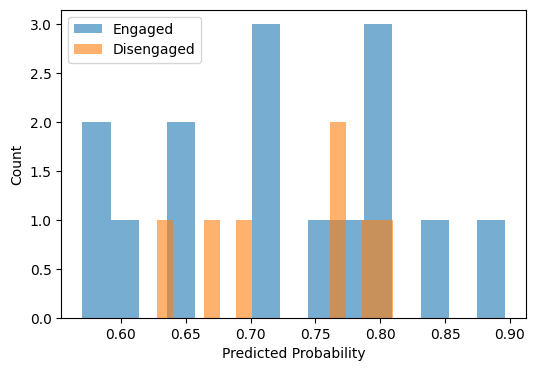

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00         7
     engaged       0.68      1.00      0.81        15

    accuracy                           0.68        22
   macro avg       0.34      0.50      0.41        22
weighted avg       0.46      0.68      0.55        22

Training p7
p7: 8 CSV files
Total child utterances: 80
Index(['F0semitoneFrom27.5Hz_sma3nz_amean',
       'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
       'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
       'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
       'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean',
       'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0',
   

/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

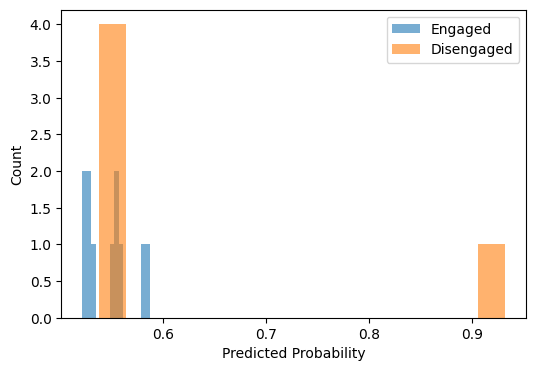

/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00         5
     engaged       0.69      1.00      0.81        11

    accuracy                           0.69        16
   macro avg       0.34      0.50      0.41        16
weighted avg       0.47      0.69      0.56        16


Fold 2/5

Training class distribution:
label
engaged       35
disengaged    16
Name: count, dtype: int64

Validation class distribution:
label
engaged       9
disengaged    4
Name: count, dtype: int64

Testing class distribution:
label
engaged       11
disengaged     5
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  

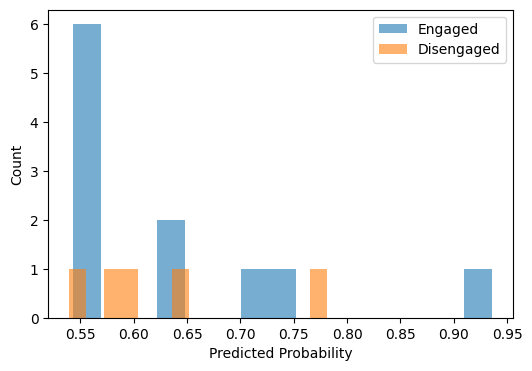

/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00         5
     engaged       0.69      1.00      0.81        11

    accuracy                           0.69        16
   macro avg       0.34      0.50      0.41        16
weighted avg       0.47      0.69      0.56        16



/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p


Fold 3/5

Training class distribution:
label
engaged       35
disengaged    16
Name: count, dtype: int64

Validation class distribution:
label
engaged       9
disengaged    4
Name: count, dtype: int64

Testing class distribution:
label
engaged       11
disengaged     5
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)
Epoch 1 Train=0.6810 Val=0.6729
Epoch 2 Train=0.6532 Val=0.6658
Epoch 3 Train=0.6526 Val=0.6573
Epoch 4 Train=0.6551 Val=0.6490
Epoch 5 Train=0.6510 Val=0.6412
Epoch 6 Train=0.6303 Val=0.6337
Epoch 7 Train=0.6257 Val=0.6264
Epoch 8 Train=0.6215 Val=0.6194
Epoch 9 Train=0.6178 Val=0.6133
Epoch 10 Train=0.5971 Val=0.6076
Ep

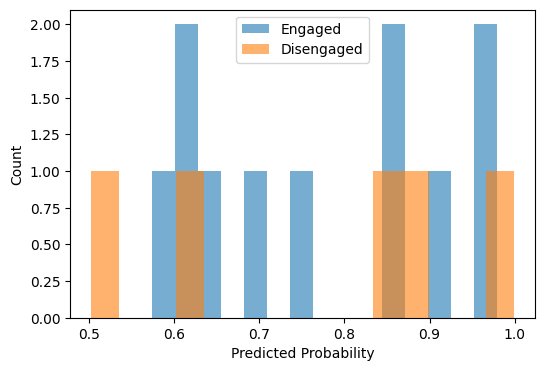

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00         5
     engaged       0.69      1.00      0.81        11

    accuracy                           0.69        16
   macro avg       0.34      0.50      0.41        16
weighted avg       0.47      0.69      0.56        16


Fold 4/5

Training class distribution:
label
engaged       35
disengaged    16
Name: count, dtype: int64

Validation class distribution:
label
engaged       9
disengaged    4
Name: count, dtype: int64

Testing class distribution:
label
engaged       11
disengaged     5
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  

/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/interactionlab/anaconda3/envs/model_env/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

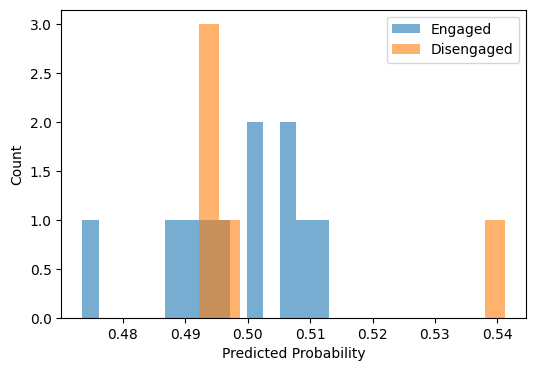

              precision    recall  f1-score   support

  disengaged       0.44      0.80      0.57         5
     engaged       0.86      0.55      0.67        11

    accuracy                           0.62        16
   macro avg       0.65      0.67      0.62        16
weighted avg       0.73      0.62      0.64        16


Fold 5/5

Training class distribution:
label
engaged       35
disengaged    16
Name: count, dtype: int64

Validation class distribution:
label
engaged       9
disengaged    4
Name: count, dtype: int64

Testing class distribution:
label
engaged       11
disengaged     5
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  

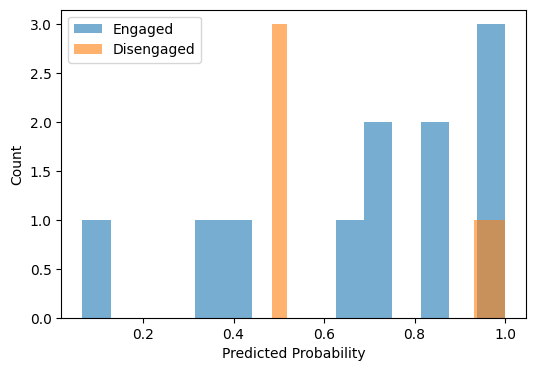

              precision    recall  f1-score   support

  disengaged       0.40      0.40      0.40         5
     engaged       0.73      0.73      0.73        11

    accuracy                           0.62        16
   macro avg       0.56      0.56      0.56        16
weighted avg       0.62      0.62      0.62        16

Training p9
p9: 5 CSV files
Total child utterances: 78
Index(['F0semitoneFrom27.5Hz_sma3nz_amean',
       'F0semitoneFrom27.5Hz_sma3nz_stddevNorm',
       'F0semitoneFrom27.5Hz_sma3nz_percentile20.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile50.0',
       'F0semitoneFrom27.5Hz_sma3nz_percentile80.0',
       'F0semitoneFrom27.5Hz_sma3nz_pctlrange0-2',
       'F0semitoneFrom27.5Hz_sma3nz_meanRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevRisingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_meanFallingSlope',
       'F0semitoneFrom27.5Hz_sma3nz_stddevFallingSlope', 'loudness_sma3_amean',
       'loudness_sma3_stddevNorm', 'loudness_sma3_percentile20.0',
   

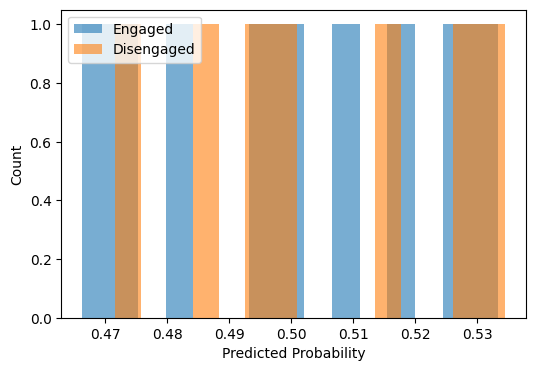

              precision    recall  f1-score   support

  disengaged       0.44      0.57      0.50         7
     engaged       0.57      0.44      0.50         9

    accuracy                           0.50        16
   macro avg       0.51      0.51      0.50        16
weighted avg       0.52      0.50      0.50        16


Fold 2/5

Training class distribution:
label
engaged       28
disengaged    21
Name: count, dtype: int64

Validation class distribution:
label
engaged       8
disengaged    5
Name: count, dtype: int64

Testing class distribution:
label
engaged       9
disengaged    7
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )


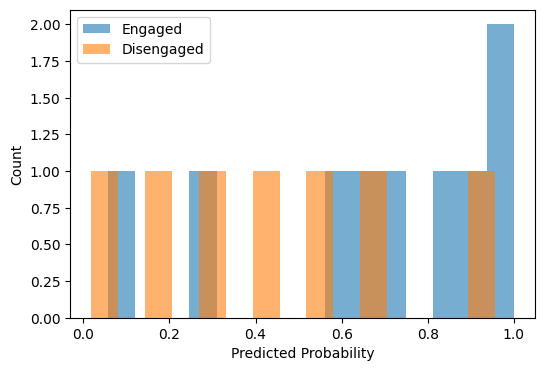

              precision    recall  f1-score   support

  disengaged       0.67      0.57      0.62         7
     engaged       0.70      0.78      0.74         9

    accuracy                           0.69        16
   macro avg       0.68      0.67      0.68        16
weighted avg       0.69      0.69      0.68        16


Fold 3/5

Training class distribution:
label
engaged       28
disengaged    21
Name: count, dtype: int64

Validation class distribution:
label
engaged       8
disengaged    5
Name: count, dtype: int64

Testing class distribution:
label
engaged       9
disengaged    7
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )


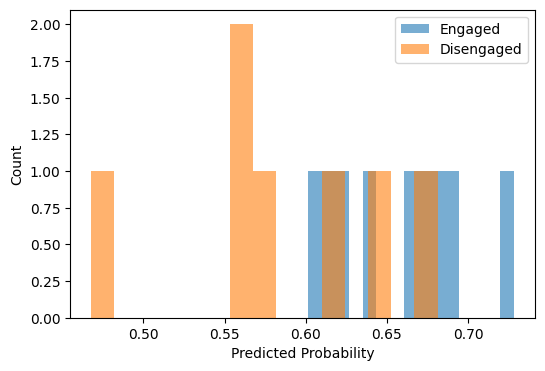

              precision    recall  f1-score   support

  disengaged       1.00      0.14      0.25         7
     engaged       0.60      1.00      0.75         9

    accuracy                           0.62        16
   macro avg       0.80      0.57      0.50        16
weighted avg       0.77      0.62      0.53        16


Fold 4/5

Training class distribution:
label
engaged       29
disengaged    21
Name: count, dtype: int64

Validation class distribution:
label
engaged       7
disengaged    6
Name: count, dtype: int64

Testing class distribution:
label
engaged       9
disengaged    6
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )


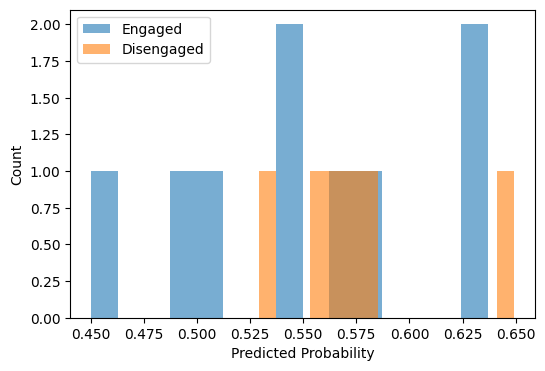

              precision    recall  f1-score   support

  disengaged       0.00      0.00      0.00         6
     engaged       0.54      0.78      0.64         9

    accuracy                           0.47        15
   macro avg       0.27      0.39      0.32        15
weighted avg       0.32      0.47      0.38        15


Fold 5/5

Training class distribution:
label
engaged       29
disengaged    21
Name: count, dtype: int64

Validation class distribution:
label
engaged       7
disengaged    6
Name: count, dtype: int64

Testing class distribution:
label
engaged       9
disengaged    6
Name: count, dtype: int64
['disengaged' 'engaged']
[0 1]
[0 1]
[0 1]
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=88, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )


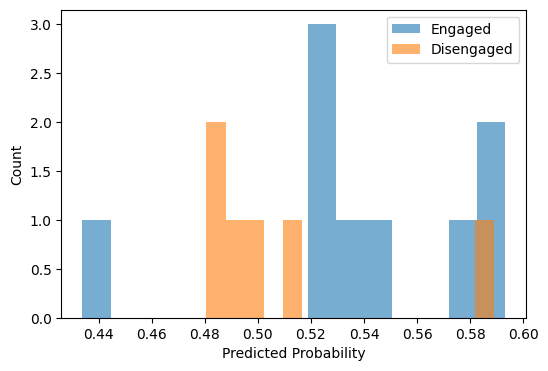

              precision    recall  f1-score   support

  disengaged       0.80      0.67      0.73         6
     engaged       0.80      0.89      0.84         9

    accuracy                           0.80        15
   macro avg       0.80      0.78      0.78        15
weighted avg       0.80      0.80      0.80        15



In [10]:
summary_results = []

participants = sorted(os.listdir(FEATURE_ROOT))

all_fold_results = []

for participant in participants:

    print(f"Training {participant}")

    # Load ALL data for this participant
    X, y = load_participant_data(participant)

    skf = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_SEED
    )

    participant_metrics = []

    for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):

        print(f"\nFold {fold}/5")

        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]

        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train,
            y_train,
            test_size=0.20,
            stratify=y_train,
            random_state=RANDOM_SEED
        )

        print("\nTraining class distribution:")
        print(y_train.value_counts())

        print("\nValidation class distribution:")
        print(y_val.value_counts())

        print("\nTesting class distribution:")
        print(y_test.value_counts())

        # Preprocess data
        X_train, X_val, X_test, y_train, y_val, y_test, scaler, encoder = preprocess_data(X_train, X_val, X_test, y_train, y_val, y_test)

        # Convert NumPy arrays into PyTorch tensors.
        X_train_tensor = torch.FloatTensor(X_train)
        X_val_tensor = torch.FloatTensor(X_val)
        X_test_tensor = torch.FloatTensor(X_test)

        # Shape of y_train, y_val, y_test is (N,), but we need (N,1) for BCEWithLogitsLoss
        y_train_tensor = torch.FloatTensor(y_train).unsqueeze(1)
        y_val_tensor = torch.FloatTensor(y_val).unsqueeze(1)
        y_test_tensor = torch.FloatTensor(y_test).unsqueeze(1)

        # Create TensorDatasets; Join features + labels
        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

        # Create DataLoaders; Batch the data
        train_loader = DataLoader(
            train_dataset,
            batch_size=32,
            shuffle=True # Shuffle training data for better generalization
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=32,
            shuffle=False
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=32,
            shuffle=False
        )

        # Build model
        model = build_model(X_train.shape[1])

        # Train model and return training history
        history = train_model(model, train_loader, val_loader)

        # Evaluate model and return evaluation metrics
        evaluation = evaluate_model(model, test_loader, encoder)

        # Append metrics for this participant to the summary results
        participant_metrics.append(evaluation["metrics"])

        # Append fold results to all_fold_results
        all_fold_results.append({
            "Participant": participant,
            "Fold": fold,
            **evaluation["metrics"]
        })
        
        # Save results
        save_results(
            f"{participant}/fold_{fold}",
            model,
            scaler,
            encoder,
            history,
            evaluation
        )
    
    metrics_df = pd.DataFrame(participant_metrics)
    
    summary_results.append({
        "Participant": participant,

        "Accuracy Mean": metrics_df["Accuracy"].mean(),
        "Accuracy Std": metrics_df["Accuracy"].std(),

        "Precision Mean": metrics_df["Precision"].mean(),
        "Precision Std": metrics_df["Precision"].std(),

        "Recall Mean": metrics_df["Recall"].mean(),
        "Recall Std": metrics_df["Recall"].std(),

        "F1 Mean": metrics_df["F1 Score"].mean(),
        "F1 Std": metrics_df["F1 Score"].std()
    })
      
pd.DataFrame(all_fold_results).to_csv(
    "fold_results.csv",
    index=False
)

# Save summary results as CSV
summary_df = pd.DataFrame(summary_results)
summary_df.to_csv(
    Path(OUTPUT_ROOT,"summary_results.csv"),
    index=False
)
    